# **ML 전처리&가공(Feature Engineering)**
* https://scikit-learn.org/stable/

* 결측 처리 : 빈값 채우기
* 이상치(Outlier) : 비정상 분포 데이터 (평균,최빈도,삭제)
* 인코딩 : 범주형 글자 -> 숫자  (남,여 -> 0,1  상,중,하->1,2,3)
* 파생피쳐 : 기존 피쳐로 의미있는 신규 피쳐 생성
* 차원축소 : 주성분 분석 (Principal Component Analysis, PCA)
* 정규화 : 데이터의 범위를 맞추는 작업 (스케일링, 규제)
 * 스케일링(로그변환, StandardScaler, MinMaxScaler, RobustScaler) : 값의 범위 맞추기
 * 규제(Regularization)

# **[1] Data Load**

<pre>
Attribute Information (in order):
        - CRIM     : 범죄율
        - ZN        :  거주지역 비율  - 25,000(평방) sq.ft. 초과
        - INDUS    : 상업지역 면적 비율
        - CHAS     찰스강 인근 (1:인근 0:x)
        - NOX      일산화질소 농도(parts per 10 million)
        - RM       : 평균 룸 수
        - AGE      : 1940년 이전에 건축된 주택 비율
        - DIS       : 직업센터와의 거리
        - RAD      : 고속도로 진입과의 거리
        - TAX       : 제산세 (rate per $10,000)
        - PTRATIO  : 교사/학생 비율
        - B            : 흑인비율 1000(Bk - 0.63)^2
        - LSTAT     : 하위계층 비율 (%)
        - price(MEDV)    :  집값

In [1]:
from sklearn import set_config
set_config(display="text")

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split   #---- 문제답 분리
from sklearn.linear_model import LinearRegression, Lasso, Ridge      #---- 회귀모델
from sklearn.metrics import mean_squared_error         #---- 평가 메트릭스
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv("../datas/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
df.columns = df.columns.str.upper()

In [5]:
df.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


# **[2] 문제지 답안지 분리**

```python
sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)


wooriinjae.ai.vision.add(num1, num2)

## 문제지(X)

In [11]:
X = df.drop(columns=["MEDV"])
X.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14


## 답안지(y)

In [12]:
y = df['MEDV']
y.head(2)

0    24.0
1    21.6
Name: MEDV, dtype: float64

## 문제지,답안지 분리(train_test_split)

In [13]:
X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234)

In [14]:
X_train7.shape, X_test3.shape,    y_train7.shape, y_test3.shape

((354, 13), (152, 13), (354,), (152,))

# **[3] 공통함수**

In [15]:
def myscore(X_train7, y_train7, X_test3, y_test3) :
    lr = LinearRegression()  
    lr.fit(X_train7, y_train7)
    pred = lr.predict(X_test3)
    mse = mean_squared_error(y_test3, pred)
    print( f"mse : {np.sqrt(mse):.4f}" )

In [16]:
myscore(X_train7, y_train7, X_test3, y_test3)

mse : 4.9105


In [17]:
def myscore222(df) :
    X = df.drop(columns=["MEDV"])
    y = df['MEDV']
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234)
    lr = LinearRegression()  
    lr.fit(X_train7, y_train7)
    pred = lr.predict(X_test3)
    mse = mean_squared_error(y_test3, pred)
    print( f"mse : {np.sqrt(mse):.4f}" )

In [13]:
myscore222(df)

mse : 4.9105


# **[4] EDA(Exploratory Data Analysis)**

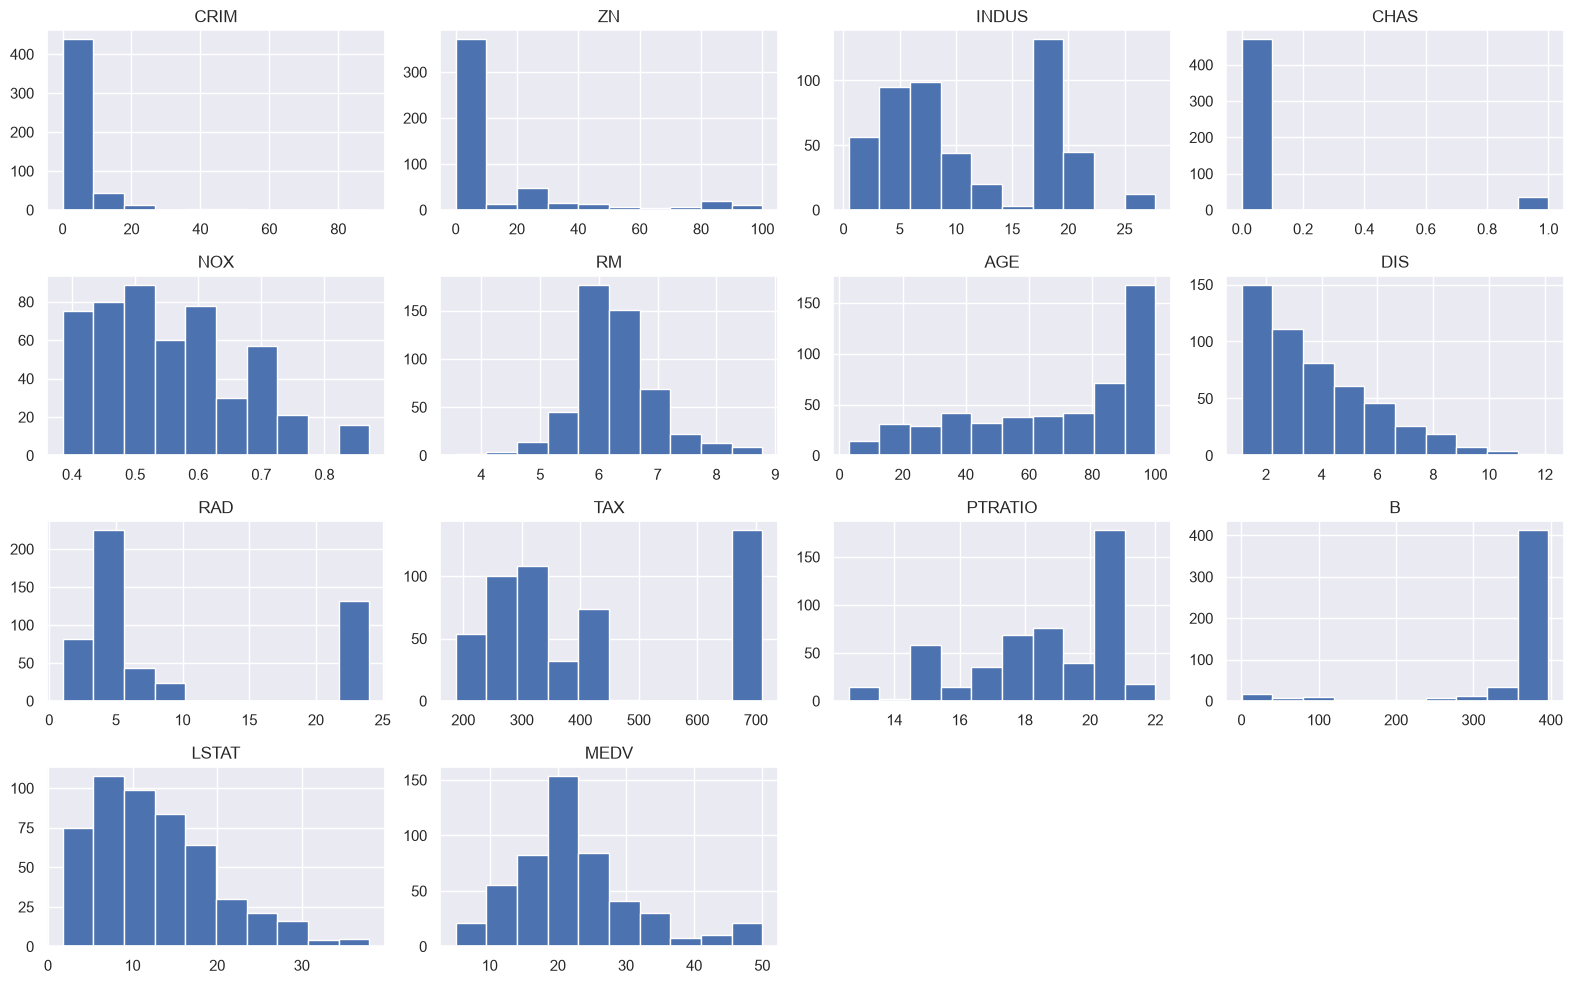

In [18]:
df.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

In [19]:
stat_df = df.describe()
stat_df
#stat_df.iloc[1, 0]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [16]:
stat_df.iloc[1, :].values

array([3.61352356e+00, 1.13636364e+01, 1.11367787e+01, 6.91699605e-02,
       5.54695059e-01, 6.28463439e+00, 6.85749012e+01, 3.79504269e+00,
       9.54940711e+00, 4.08237154e+02, 1.84555336e+01, 3.56674032e+02,
       1.26530632e+01, 2.25328063e+01])

## **상관분석**

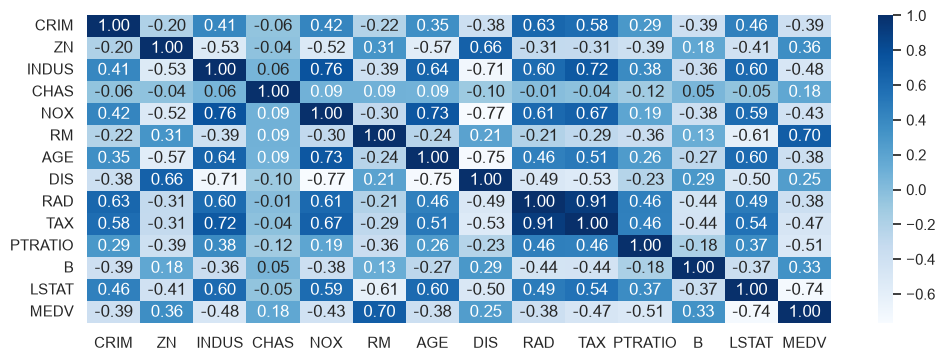

In [20]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.show()

* <font color='red'><b>traget(MEDV) +상관관계 (RM) -상관관계(LSTAT)
* <font color='red'><b>다중공선 : TAX-RAD

# **[5] 전처리&가공**

<pre>X 결측 처리 : 빈값 채우기
X 인코딩 : 범주형 글자 -> 숫자 (남,여 -> 0,1 상,중,하->1,2,3)

## 이상치(Outlier) : 비정상 분포 데이터 (평균,최빈도,삭제)

<img src="https://mblogthumb-phinf.pstatic.net/MjAxODA1MjBfODEg/MDAxNTI2Nzc5ODg5NTAz.ajSTPNJH5ajYba4n_dQIfwI2W9QWD7HTyZ0HV18nzLEg.pocbFj4K4xCHQ33K6WnNuFQnIBB9Yx2rsSkM5eVyjTwg.PNG.jjy0501/598px-Boxplot_vs_PDF.svg.png?type=w2" width=600>

### **평균 +- 3편차**

In [23]:
m  = df['RM'].mean()
s3 = df['RM'].std() * 3
print(m, s3)
print(m - s3 , m + s3)

6.284634387351779 2.10785143024597
4.176782957105809 8.392485817597748


In [24]:
df['RM'].count()

np.int64(506)

In [25]:
df [ df['RM'] > m+s3 ] ['RM']

225    8.725
257    8.704
262    8.398
364    8.780
Name: RM, dtype: float64

### **IQR**

In [26]:
Q1         = np.percentile(df['RM'], 25)
Q3         = np.percentile(df['RM'], 75)
IQR = Q3 - Q1
print(IQR)
print( Q1 - (1.5*IQR),  Q3 + (1.5*IQR) )

0.7380000000000004
4.778499999999999 7.730500000000001


In [22]:
df [ df['RM'] > Q3 + (1.5*IQR)   ] ['RM']

97     8.069
98     7.820
162    7.802
163    8.375
166    7.929
180    7.765
186    7.831
195    7.875
203    7.853
204    8.034
224    8.266
225    8.725
226    8.040
232    8.337
233    8.247
253    8.259
257    8.704
262    8.398
267    8.297
280    7.820
283    7.923
364    8.780
Name: RM, dtype: float64

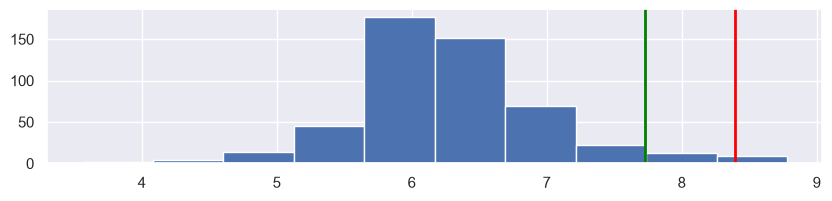

In [27]:
plt.figure(figsize=(10, 2)) 
df['RM'].hist()
plt.axvline(m + s3         , 0, 1        , color='red'   , linestyle='-', linewidth=2)   #----- 수직선
plt.axvline(Q3 + (1.5*IQR) , 0, 1        , color='green' , linestyle='-', linewidth=2)   #----- 수직선

plt.show()

### **박스플롯/스캐터**

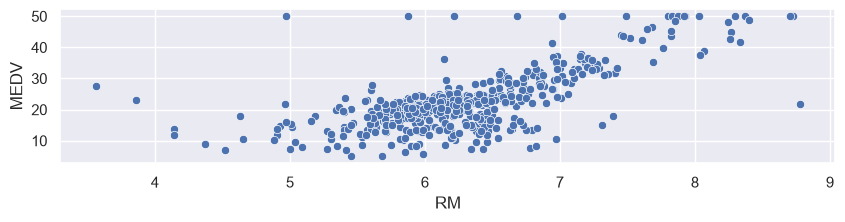

In [28]:
plt.figure(figsize=(10, 2))
sns.scatterplot(x="RM", y="MEDV", data=df)
plt.show()

* <b>RM>8 MEDV<30

In [29]:
df  [ (df['RM']>8) & (df['MEDV']<30)]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
364,3.47428,0.0,18.1,1,0.718,8.78,82.9,1.9047,24,666,20.2,354.55,5.29,21.9


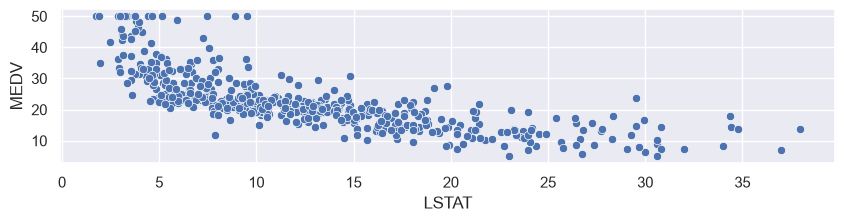

In [30]:
plt.figure(figsize=(10, 2))
sns.scatterplot(x="LSTAT", y="MEDV", data=df)
plt.show()

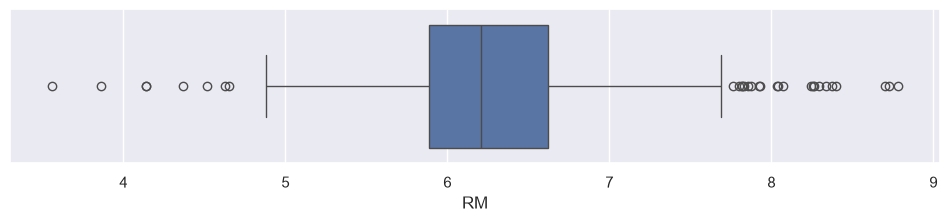

In [27]:
plt.figure(figsize=(12, 2))
sns.boxplot(x="RM", data=df)
plt.show()

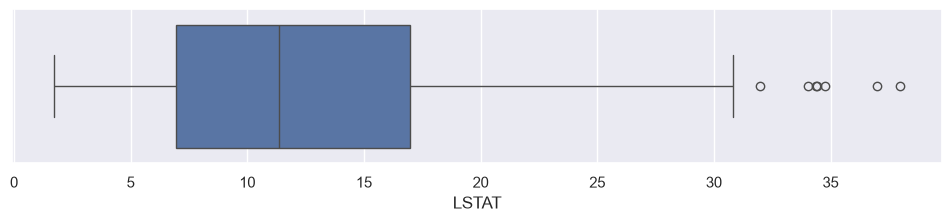

In [31]:
plt.figure(figsize=(12, 2))
sns.boxplot(x="LSTAT",  data=df)
plt.show()

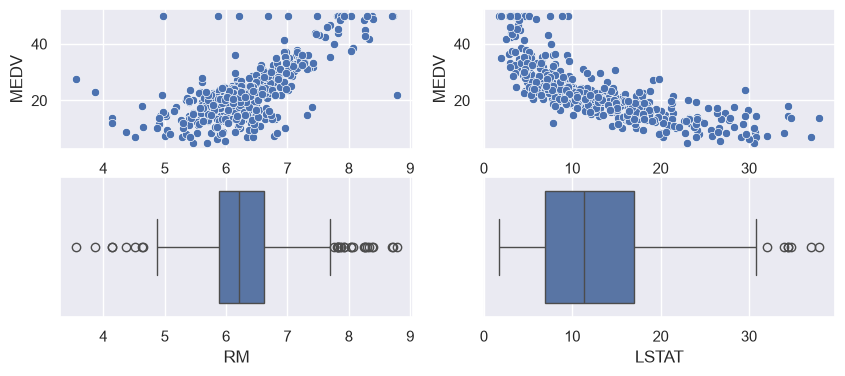

In [32]:
plt.figure(figsize=(10, 4)) 

plt.subplot(2,2,      1)         #---------------------------2행2열의 1번째
sns.scatterplot(x="RM", y="MEDV", data=df)

plt.subplot(2,2,      2)         #---------------------------2행2열의 2번째
sns.scatterplot(x="LSTAT", y="MEDV", data=df)

plt.subplot(2,2,      3)         #---------------------------2행2열의 3번째
sns.boxplot(x="RM",  data=df)

plt.subplot(2,2,      4)         #---------------------------2행2열의 4번째
sns.boxplot(x="LSTAT",  data=df)

plt.show()

### 아웃라이어 삭제 후 점수보기

* <b>연습용

In [33]:
aa = pd.DataFrame({"A":[1,2,3,4,5,6],"B":[1,2,3,4,5,6]})
#aa = aa.drop(columns=["A"])    #---칸지우기
#aa = aa.drop(['A'], axis=1)    #---칸지우기
#aa = aa.drop([1,2,3], axis=0)  #---줄지우기
aa

,A,B
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,6,6


In [34]:
df[ (df['RM']>8) & (df['MEDV']<30)]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
364,3.47428,0.0,18.1,1,0.718,8.78,82.9,1.9047,24,666,20.2,354.55,5.29,21.9


In [35]:
df[ (df['RM']>8) & (df['MEDV']<30)].index.tolist() 

[364]

In [36]:
idx_list = df[ (df['RM']>8) & (df['MEDV']<30)].index.tolist() 
print(df.shape)
df = df.drop(idx_list, axis=0)  #---줄지우기
print(df.shape)

(506, 14)
(505, 14)


In [37]:
myscore222(df)

mse : 4.4170


## 왜도 & 첨도

* <b>왜도 (Skewness)</b>
    - 데이터 분포의 좌우 비대칭도
    - 0: 좌우 대칭(정규분포)
    - 양수(+): 오른쪽으로 긴 꼬리
    - 음수(-): 왼쪽으로 긴 꼬리
* <b>첨도 (Kurtosis)</b>
    - 데이터 분포의 뾰족한 정도
    - 3 (일부 프로그램은 0을 기준): 정규분포
    - 3보다 큼 (양수): 정규분포보다 더 뾰족하고 꼬리가 두껍다(이상치 많음)
    - 3보다 작음 (음수): 정규분포보다 완만하고 꼬리가 얇다

In [38]:
df.skew()

CRIM       5.217923
ZN         2.222377
INDUS      0.299608
CHAS       3.463574
NOX        0.735741
RM         0.347853
AGE       -0.596065
DIS        1.009303
RAD        1.012875
TAX        0.675963
PTRATIO   -0.799325
B         -2.887676
LSTAT      0.904476
MEDV       1.106616
dtype: float64

In [39]:
df.kurt()

CRIM       37.051284
ZN          4.015557
INDUS      -1.229492
CHAS       10.036078
NOX        -0.046826
RM          1.811573
AGE        -0.972219
DIS         0.483707
RAD        -0.849783
TAX        -1.131453
PTRATIO    -0.289435
B           7.207294
LSTAT       0.491423
MEDV        1.485808
dtype: float64

## 로그변화(Log Scaling)
* <font color='red'><b> 회귀에서 y에 대해서느 일반적으로 로그 변화 필수

In [40]:
np.log(1000), np.exp(6.907755278982137)

(np.float64(6.907755278982137), np.float64(999.9999999999998))

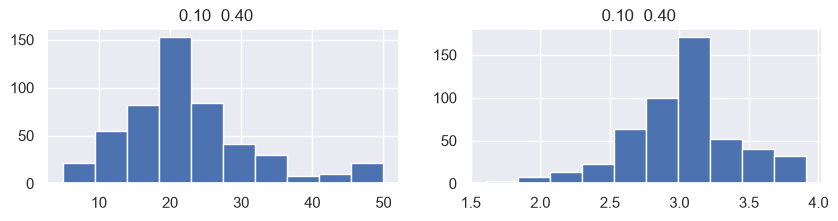

In [41]:
plt.figure(figsize=(10, 2)) 

plt.subplot(1,2,      1)         #---------------------------1행2열의 1번째
df['MEDV'].hist()
plt.title(f"{np.log(df['MEDV'].skew()):.2f}  {np.log(df['MEDV'].kurt()):.2f}   ")

plt.subplot(1,2,      2)         #---------------------------1행2열의 2번째
np.log(df['MEDV']).hist()
plt.title(f"{np.log(df['MEDV'].skew()):.2f}  {np.log(df['MEDV'].kurt()):.2f}   ")

plt.show()


## 정규화(Normalization / Scaling)
* 데이터의 범위를 보통 0과 1 사이 맞추는 작업 (스케일링, 규제)

```python
class sklearn.preprocessing.StandardScaler(*, copy=True, with_mean=True, with_std=True)
class sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
class sklearn.preprocessing.RobustScaler(*, with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), copy=True, unit_variance=False)



* StandardScaler()
    * z = (x - u) / s
    * 표준화(Standardization)란 단위나 범위가 다른 서로 다른 데이터를 평균이 0, 표준편차가 1인 표준정규분포로 변환하여 공정하게 비교할 수 있도록 만드는 과정
* MinMaxScaler
    * tuple (min, max), default=(0, 1)
* RobustScaler
    *  0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)

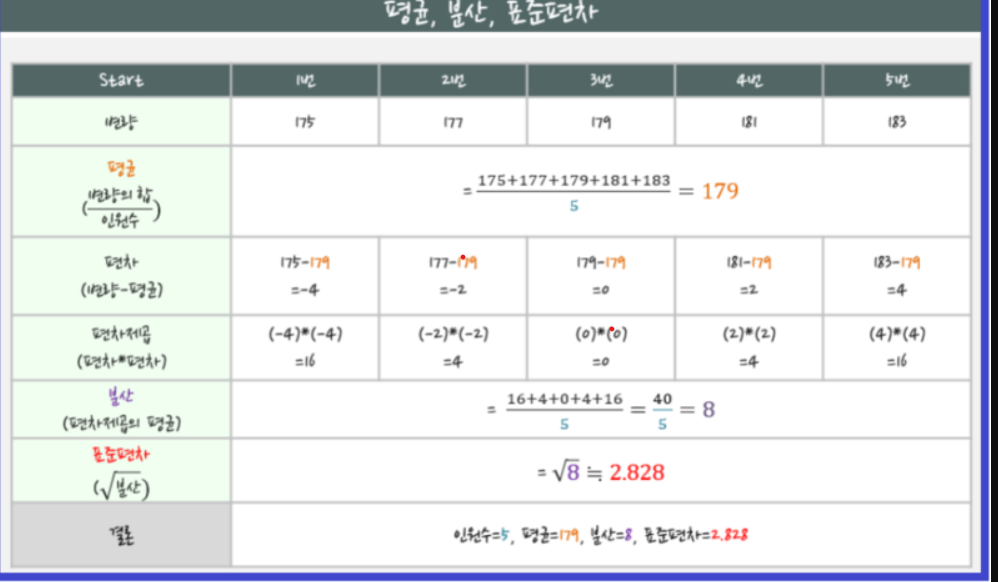

In [42]:
x = [175, 177,179,181,183]
m = (175+ 177+179+181+183) / 5
v = ((m-175)**2 + (m-177)**2 + (m-179)**2 + (m-181)**2 + (m-183)**2) / 5
std = np.sqrt(v)
print(m, v, std)

179.0 8.0 2.8284271247461903


In [43]:

ss= StandardScaler()
#ms= MinMaxScaler()
#rs= RobustScaler
ss.fit(X_train7)
X_train7_scale = ss.transform(X_train7)
X_test3_scale = ss.transform(X_test3)
print(X_train7_scale[0])

myscore(X_train7, y_train7, X_test3, y_test3)


[-0.39236069 -0.46448399 -1.23341932 -0.28154625 -0.9491409   1.70240563
 -0.21292278 -0.12365899 -0.8605777  -0.76576572 -0.21697578  0.45546336
 -0.91480728]
mse : 4.9105


## 파생피쳐 : 기존 피쳐로 의미있는 신규 피쳐 생성

In [44]:
df['TAX_RATIO'] = df['TAX']/ df['MEDV']
df.head(2)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAX_RATIO
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0,12.333333
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6,11.203704


In [45]:
df.shape

(505, 15)

In [46]:
myscore222(df)

mse : 3.9661


## 차원축소 : 주성분 분석 (Principal Component Analysis, PCA)
* PCA(주성분 분석, Principal Component Analysis)
* 고차원의 데이터를 정보 손실을 최소화하면서 저차원으로 줄이는 차원 축소 통계 기법

```python

class sklearn.decomposition.PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto',
 tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)

In [47]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'TAX_RATIO'],
      dtype='str')

In [48]:

pca = PCA(n_components=12)
pca.fit(X)
X_pca=pca.transform(X)
print(pca.explained_variance_ratio_)
print(X_pca)

X_train7, X_test3,    y_train7, y_test3 = train_test_split( X_pca, y, test_size=0.3, random_state=1234)

myscore(X_train7, y_train7 , X_test3, y_test3)


[8.05823175e-01 1.63051968e-01 2.13486092e-02 6.95699061e-03
 1.29995193e-03 7.27220158e-04 4.19044539e-04 2.48538539e-04
 8.53912023e-05 3.08071548e-05 6.65623182e-06 1.56778461e-06]
[[-1.19818843e+02  5.56005586e+00  3.17269264e+00 ... -3.29154269e-01
  -3.78374287e-01 -7.13108946e-02]
 [-1.68890155e+02 -1.01162086e+01  3.07818868e+01 ...  1.29980968e+00
  -4.86740794e-02 -9.47343278e-02]
 [-1.69311707e+02 -1.40805323e+01  1.67536282e+01 ...  9.10645729e-01
   4.67469154e-01 -1.07257460e-01]
 ...
 [-1.38387163e+02 -9.38092201e-01  3.72851813e+01 ... -1.34950212e+00
   2.97952531e-01 -1.04654969e-01]
 [-1.37505173e+02 -4.25182510e+00  3.59883419e+01 ... -1.18889458e+00
   1.94149871e-01 -9.54593524e-02]
 [-1.39190333e+02 -1.00906423e+00  2.97724323e+01 ... -1.29162070e+00
  -4.16189839e-01 -7.03283698e-02]]
mse : 4.8682


In [49]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAX_RATIO
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,12.333333
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,11.203704
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,6.974063
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,6.646707
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,6.132597


# **AI 사용**
1. csv 파일 준비 --> 읽어서 df 만들기
2. df 데이터 보기(결측, 컬럼이름,데이터)
3. 타겟피쳐 선별 (MEDV) 회귀
4. EDA(시각화)
    - 히스토그램
       : 정규분포여부(왜도,첨도,로그변환필요여부)
    - 히트맵(상관분석)
       : 타겟(MEDV)에 가장 많은 영향을 주는 피쳐
       : 피쳐-피쳐 간의 영향도 분석
    - 박스플롯,스캐터
       : 영향도 분석을 통해 선별된 피쳐 중심으로 아웃라이어 선별
 5. 전처리 & 가공
   - EDA에서 분석된 피쳐들 중심으로 전처리 가공
   - 정규화(스케일링,로그변환), 인코딩, 결측처리, 파생피쳐, PCA 
      위 처리를 하면서 개별 개별 점수들을 확인
      만약 점수가 좋다면 반영/아니다 하면 해당 처리는 버림
6. 모델준비/학습/예측/평가
   - LinearRegression
   - np.sqrt(mse) 점수 평가

# **규제**

* **L1 정규화 (Lasso 회귀)**
    - 가중치의 절댓값의 총합 
    - 중요하지 않은 가중치를 완전히 0으로 만들어 제거
    - 피쳐 셀렉션
    - $ Loss = Cost(y, \hat{y}) + \lambda \sum_{i=1}^{n} \Vert w \Vert_i $
* **L2 정규화 (Ridge 회귀)**
    - 가중치의 제곱 총합  
    - 가중치 크기를 완만하게 줄여나가며 모델 새성
    - 안정적 모델 생성
    - $ Loss = Cost(y, \hat{y}) + \lambda \sum_{i=1}^{n} w_i^2 $

In [72]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAX_RATIO
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,12.333333
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,11.203704
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,6.974063
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,6.646707
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,6.132597


In [73]:
X = df.drop('MEDV', axis=1)
y= df['MEDV']
X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234)

In [74]:
model1 =Lasso( alpha=1.0, random_state=None)
model1.fit(X_train7, y_train7)
pred = model1.predict(X_test3)
mse = mean_squared_error(y_test3, pred)
print( f"mse : {np.sqrt(mse):.4f}" )

mse : 4.7411


In [75]:
model1.coef_

array([ 0.04612963,  0.06817035, -0.02323332,  0.        , -0.        ,
        0.91285914,  0.00561297, -0.75010727,  0.24341181, -0.        ,
       -0.57920277,  0.00499311, -0.52940062, -0.22645134])

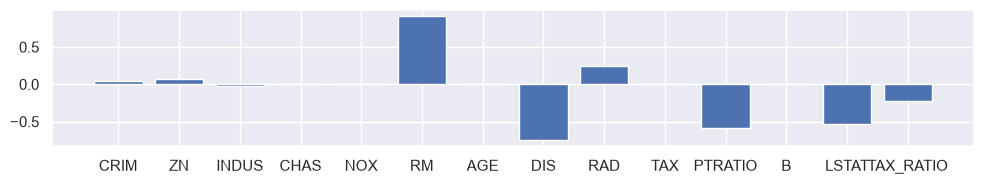

In [76]:
plt.figure(figsize=(10, 2)) 
plt.bar(X_train7.columns,model1.coef_)
plt.tight_layout()
plt.show()

In [77]:
model2 =Ridge( alpha=1.0,random_state=None)
model2.fit(X_train7, y_train7)
pred = model2.predict(X_test3)
mse = mean_squared_error(y_test3, pred)
print( f"mse : {np.sqrt(mse):.4f}" )


mse : 3.9342


In [78]:
model2.coef_

array([ 5.03743645e-02,  6.08347767e-02, -7.01059866e-02,  2.27394656e+00,
       -8.51475858e+00,  3.97726537e+00, -1.71496182e-02, -1.44035635e+00,
        2.31915168e-01,  4.66759426e-03, -6.90959059e-01,  6.89008435e-03,
       -3.11173032e-01, -2.41413458e-01])

Ridge mse : 3.9342


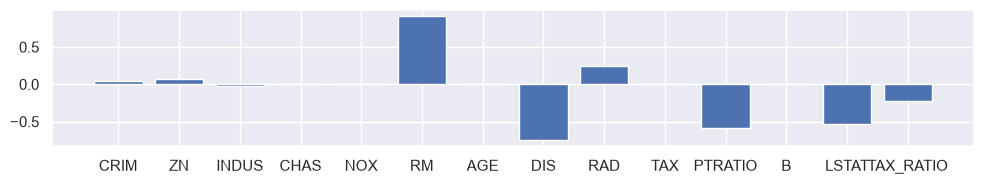

Ridge mse : 3.9342


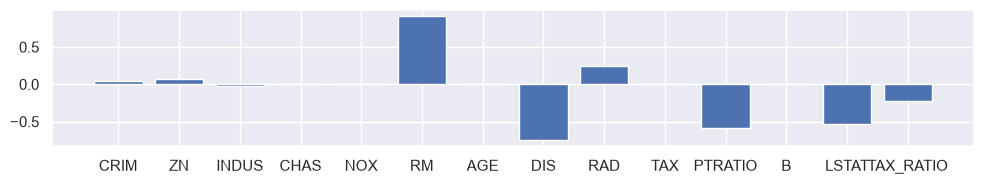

In [80]:
for model in [Ridge( alpha=1.0,random_state=None),
             Lasso( alpha=1.0,random_state=None)]:


    model2.fit(X_train7, y_train7)
    pred = model2.predict(X_test3)
    mse = mean_squared_error(y_test3, pred)
    print(f"{model2.__class__.__name__} mse : {np.sqrt(mse):.4f}")
    
    plt.figure(figsize=(10, 2)) 
    plt.bar(X_train7.columns,model1.coef_)
    plt.tight_layout()
    plt.show()

* 규제 튜닝

Ridge mse : 3.9342


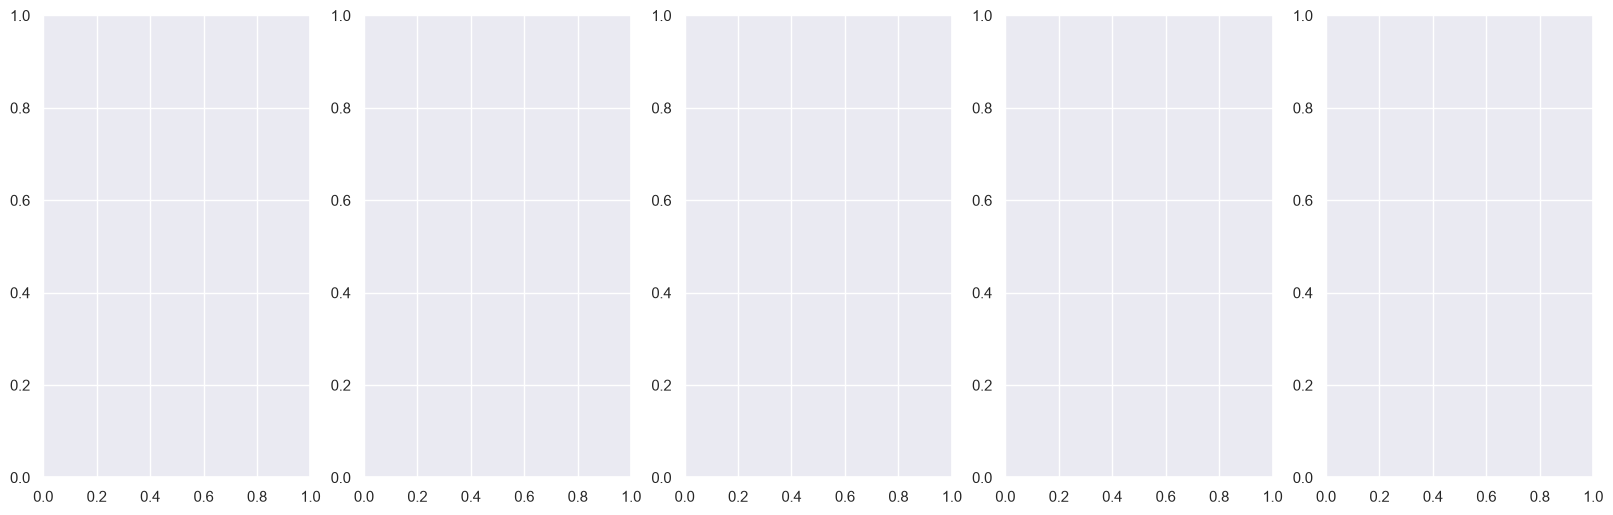

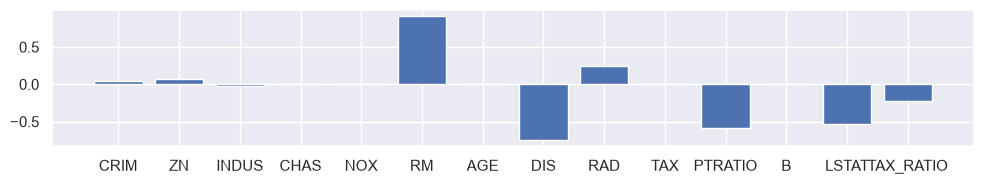

Ridge mse : 3.9342


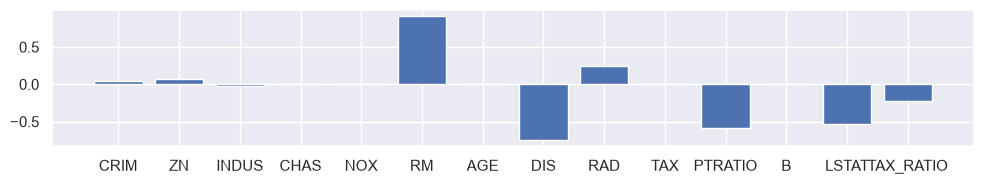

Ridge mse : 3.9342


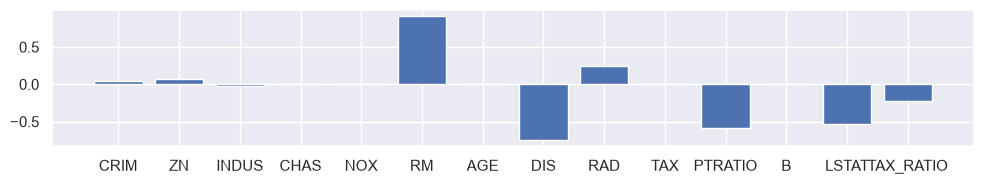

Ridge mse : 3.9342


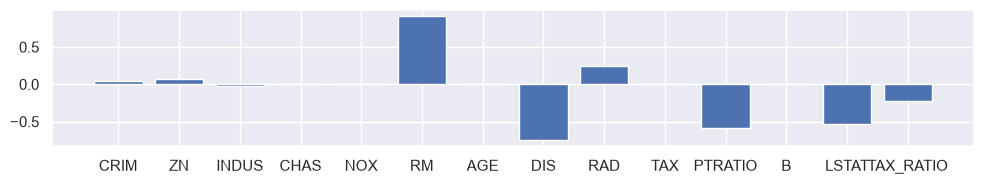

Ridge mse : 3.9342


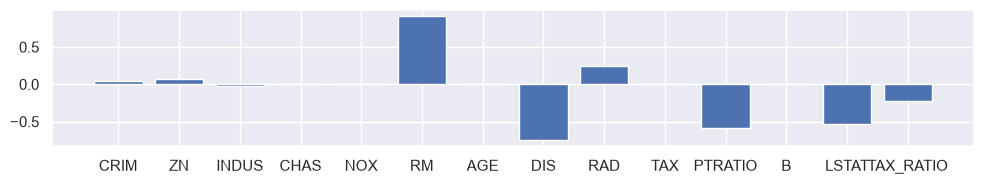

Ridge mse : 3.9342


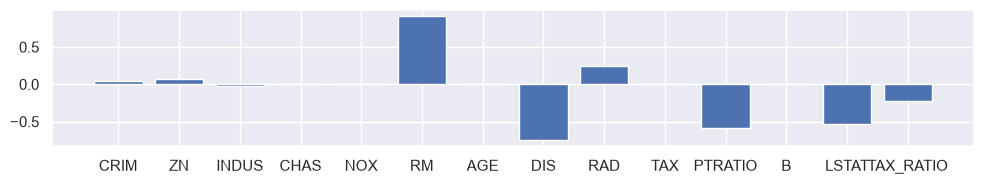

Ridge mse : 3.9342


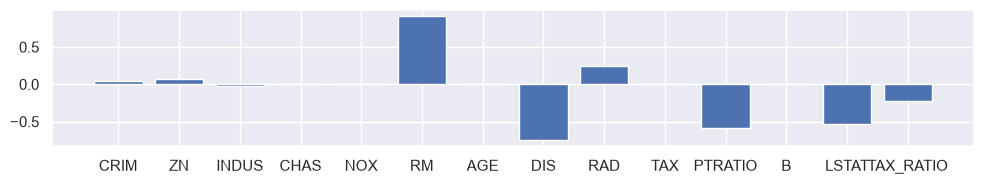

Ridge mse : 3.9342


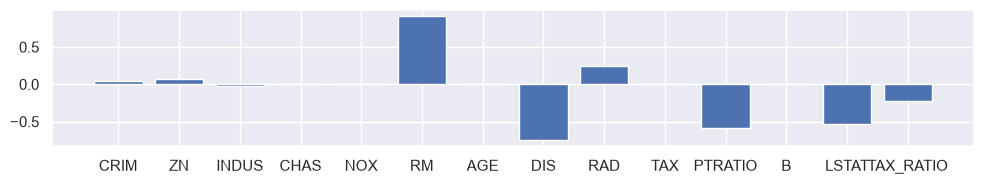

Ridge mse : 3.9342


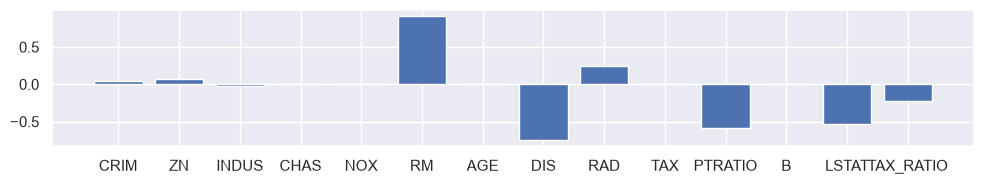

Ridge mse : 3.9342


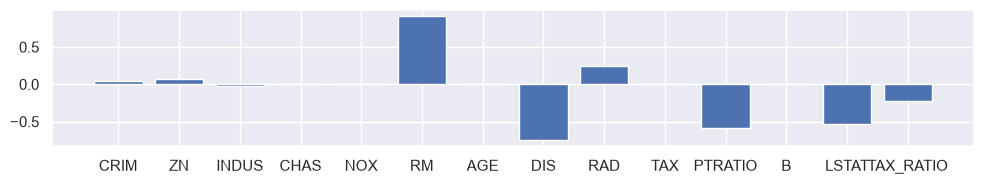

In [82]:
fig, axes = plt.subplots(1,5, figsize= (20,6))
for MY_ALPHA in [0.01,0.1, 1.0, 10,100]:
 for model in [Ridge( alpha=1.0,random_state=None),
             Lasso( alpha=1.0,random_state=None)]:


    model2.fit(X_train7, y_train7)
    pred = model2.predict(X_test3)
    mse = mean_squared_error(y_test3, pred)
    print(f"{model2.__class__.__name__} mse : {np.sqrt(mse):.4f}")
    
    plt.figure(figsize=(10, 2)) 
    plt.bar(X_train7.columns,model1.coef_)
    plt.tight_layout()
    plt.show()


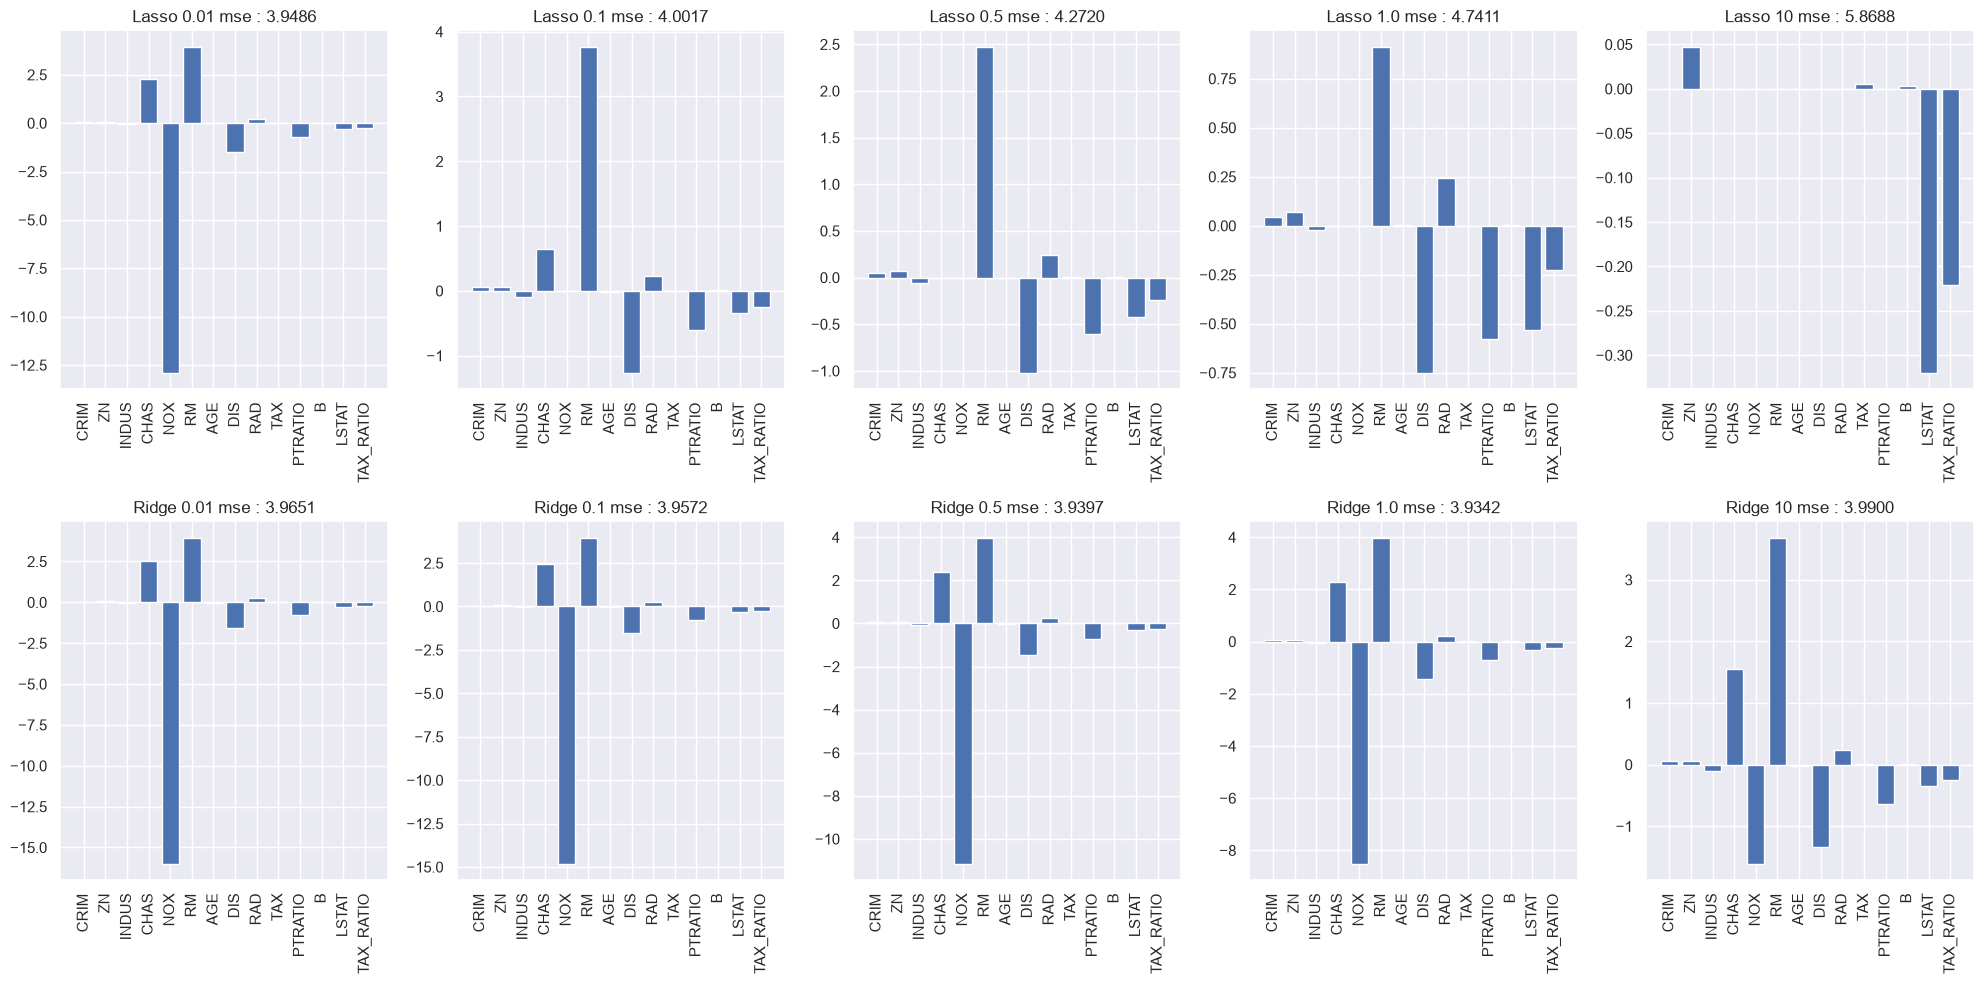

In [85]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for 칸, my_alpha in enumerate ([0.01, 0.1, 0.5, 1.0, 10]) :
    for 줄, model in enumerate([Lasso(alpha=my_alpha, random_state=1234), 
                                Ridge(alpha=my_alpha, random_state=1234)]) :
        
        model.fit(X_train7, y_train7)
        pred = model.predict(X_test3)
        mse = mean_squared_error(y_test3, pred) 
        #print( f"{model.__class__.__name__} mse : {np.sqrt(mse):.4f}" )
        
        axes[줄, 칸].bar(X_train7.columns, model.coef_)
        axes[줄, 칸].set_title(f"{model.__class__.__name__} {my_alpha} mse : {np.sqrt(mse):.4f}")
        axes[줄, 칸].tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.show()